# Centroid vs. Phase-Average Comparison

## Objective

This notebook performs a quantitative comparison between the **cluster centroids** obtained from unsupervised clustering of the turbulent jet flow snapshots and the **phase-averaged velocity fields** acquired via hardware-triggered phase-locking.

The central question is: **do the unsupervised clusters correspond to specific phases of the actuation cycle?** If centroid $\mathbf{C}_k$ is geometrically close to phase-average $\mathbf{P}_i$, it demonstrates that the clustering algorithm has blindly recovered the deterministic, phase-locked vortex structures without any trigger information — validating the **Manifold Hypothesis**.

---


In [1]:
# ============================================================================
# Configuration — change only this cell to analyze a different run
# ============================================================================

RUN_ID  = 2       # experimental run number
K       = 20      # number of clusters (should match N_phases = 20)
ST_ACT  = 0.05    # actuation Strouhal number for Run 2

# Directory layout (relative to notebook location)
COMPRESSED_DATA_DIR = 'compressed_data'
SPCA_DATA_DIR       = 'SPCA_data'
CLUSTER_DATA_DIR    = 'clustering_data'
PHASE_AVG_DIR       = 'phase_avg_data'
SPATIAL_GRID_FILE   = 'spatial_grid.npz'
FIGURE_DIR          = 'figures'

import os
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(CLUSTER_DATA_DIR, exist_ok=True)

## Imports and Utilities

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
import gc
import time
import os

# Use LaTeX-style rendering in labels
plt.rc('text', usetex=False)
plt.rcParams.update({'font.size': 12})

---

## Section 1: Data Loading

In [3]:
# ============================================================================
# Load spatial grid
# ============================================================================
grid = np.load(SPATIAL_GRID_FILE, allow_pickle=False)
X_grid = grid['X_grid']  # shape (269, 319)
Y_grid = grid['Y_grid']  # shape (269, 319)
NX, NY = X_grid.shape
spatial_dof = 2 * NX * NY  # = 171622

print(f'Spatial grid loaded: NX={NX}, NY={NY}, spatial_dof={spatial_dof}')

# ============================================================================
# Load phase-averaged data
# ============================================================================
phase_avg_path = os.path.join(PHASE_AVG_DIR, f'RUN{RUN_ID}_phase_avg.npz')
if not os.path.isfile(phase_avg_path):
    raise FileNotFoundError(
        f'Phase-average file not found: {phase_avg_path}\n'
        f'Run: python extract_phase_averages.py --run {RUN_ID}'
    )

pa_data = np.load(phase_avg_path, allow_pickle=False)
Uph = pa_data['Uph']  # (N_phases, NX, NY)
Vph = pa_data['Vph']  # (N_phases, NX, NY)
Um  = pa_data['Um']   # (NX, NY)
Vm  = pa_data['Vm']   # (NX, NY)

N_phases = Uph.shape[0]
print(f'Phase-average data loaded: N_phases={N_phases}')
print(f'  Uph shape: {Uph.shape}')
print(f'  Vph shape: {Vph.shape}')
print(f'  Um  shape: {Um.shape}')
print(f'  Vm  shape: {Vm.shape}')

# ============================================================================
# Load SPCA scores (temporal coefficients)
# ============================================================================
spca_path = os.path.join(SPCA_DATA_DIR, f'RUN{RUN_ID}_PIV_SPCA.npz')
spca_data = np.load(spca_path, allow_pickle=False)
spca_scores = spca_data['scores']  # (2030, 30)
print(f'SPCA scores loaded: shape = {spca_scores.shape}')

Spatial grid loaded: NX=269, NY=319, spatial_dof=171622
Phase-average data loaded: N_phases=20
  Uph shape: (20, 269, 319)
  Vph shape: (20, 269, 319)
  Um  shape: (269, 319)
  Vm  shape: (269, 319)
SPCA scores loaded: shape = (2030, 30)


---

## Section 2: K=20 Clustering and Centroid Computation


In [4]:
# ============================================================================
# Step 2a: KMeans clustering with K=20 on SPCA scores
# ============================================================================

print(f'Running KMeans with K={K} on SPCA scores (shape {spca_scores.shape})...')
t0 = time.time()

kmeans = KMeans(
    n_clusters=K,
    n_init=20,          # multiple initializations for robustness
    max_iter=500,
    random_state=42
)
labels = kmeans.fit_predict(spca_scores)  # shape (2030,)

elapsed = time.time() - t0
print(f'  KMeans completed in {elapsed:.1f}s')
print(f'  Labels shape: {labels.shape}')
print(f'  Unique labels: {np.unique(labels)}')
print(f'  Cluster sizes: {[np.sum(labels == k) for k in range(K)]}')

# Save labels for reuse
labels_path = os.path.join(CLUSTER_DATA_DIR, f'RUN{RUN_ID}_PIV_labels_K{K}.npz')
np.savez_compressed(labels_path, labels=labels.astype(np.int32))
print(f'  Labels saved to {labels_path}')

Running KMeans with K=20 on SPCA scores (shape (2030, 30))...
  KMeans completed in 4.1s
  Labels shape: (2030,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
  Cluster sizes: [np.int64(101), np.int64(101), np.int64(102), np.int64(102), np.int64(101), np.int64(102), np.int64(102), np.int64(102), np.int64(101), np.int64(101), np.int64(101), np.int64(102), np.int64(101), np.int64(102), np.int64(102), np.int64(101), np.int64(101), np.int64(101), np.int64(102), np.int64(102)]
  Labels saved to clustering_data\RUN2_PIV_labels_K20.npz


In [5]:
# ============================================================================
# Step 2b: Compute cluster centroids from raw fluctuating velocity fields
# ============================================================================
# The compressed data file is ~2.6 GB. We use memory-mapped access
# to compute centroid accumulators incrementally, one snapshot at a time.

compressed_path = os.path.join(COMPRESSED_DATA_DIR, f'RUN{RUN_ID}_PIV_compressed.npz')
print(f'Computing centroids from {compressed_path} using memory-mapped access...')
t0 = time.time()

# Memory-map the compressed file
comp_data = np.load(compressed_path, allow_pickle=False, mmap_mode='r')
u_mmap = comp_data['u']   # shape (2030, 269, 319)
v_mmap = comp_data['v']   # shape (2030, 269, 319)

print(f'  u shape: {u_mmap.shape},  dtype: {u_mmap.dtype}')
print(f'  v shape: {v_mmap.shape},  dtype: {v_mmap.dtype}')

# Sanity check
assert u_mmap.shape[0] == labels.shape[0], \
    f'Mismatch: {u_mmap.shape[0]} snapshots vs {labels.shape[0]} labels'

half = NX * NY  # = 85811

# Initialize centroid accumulators
centroids = np.zeros((K, spatial_dof), dtype=np.float64)
cluster_counts = np.zeros(K, dtype=int)

# Accumulate centroids incrementally
for n in range(u_mmap.shape[0]):
    k = labels[n]
    cluster_counts[k] += 1
    u_snap = u_mmap[n].flatten()  # (NX*NY,)
    v_snap = v_mmap[n].flatten()  # (NX*NY,)
    centroids[k, :half]  += u_snap
    centroids[k, half:]  += v_snap

# Divide by count to get the mean
for k in range(K):
    if cluster_counts[k] > 0:
        centroids[k] /= cluster_counts[k]

# Release memory-mapped arrays
del comp_data, u_mmap, v_mmap
gc.collect()

elapsed = time.time() - t0
print(f'\nCentroid computation completed in {elapsed:.1f}s')
print(f'Centroids shape: {centroids.shape}')
print(f'\nCluster membership:')
for k in range(K):
    print(f'  Cluster {k:3d}: {cluster_counts[k]:5d} snapshots '
          f'({100*cluster_counts[k]/labels.shape[0]:.1f}%)')

Computing centroids from compressed_data\RUN2_PIV_compressed.npz using memory-mapped access...
  u shape: (2030, 269, 319),  dtype: float64
  v shape: (2030, 269, 319),  dtype: float64

Centroid computation completed in 11.6s
Centroids shape: (20, 171622)

Cluster membership:
  Cluster   0:   101 snapshots (5.0%)
  Cluster   1:   101 snapshots (5.0%)
  Cluster   2:   102 snapshots (5.0%)
  Cluster   3:   102 snapshots (5.0%)
  Cluster   4:   101 snapshots (5.0%)
  Cluster   5:   102 snapshots (5.0%)
  Cluster   6:   102 snapshots (5.0%)
  Cluster   7:   102 snapshots (5.0%)
  Cluster   8:   101 snapshots (5.0%)
  Cluster   9:   101 snapshots (5.0%)
  Cluster  10:   101 snapshots (5.0%)
  Cluster  11:   102 snapshots (5.0%)
  Cluster  12:   101 snapshots (5.0%)
  Cluster  13:   102 snapshots (5.0%)
  Cluster  14:   102 snapshots (5.0%)
  Cluster  15:   101 snapshots (5.0%)
  Cluster  16:   101 snapshots (5.0%)
  Cluster  17:   101 snapshots (5.0%)
  Cluster  18:   102 snapshots (5.0%)
 

---

## Section 3: Fluctuating Phase-Average Computation

In [6]:
# ============================================================================
# Compute fluctuating phase-averages
# ============================================================================

# Subtract the time-mean to get fluctuating phase-averages
# Uph has shape (N_phases, NX, NY), Um has shape (NX, NY)
Uph_fluct = Uph - Um[np.newaxis, :, :]  # broadcasting: (20, 269, 319)
Vph_fluct = Vph - Vm[np.newaxis, :, :]  # broadcasting: (20, 269, 319)

# Flatten into snapshot vectors of shape (N_phases, 2*NX*NY)
phase_avg_fluct = np.zeros((N_phases, spatial_dof), dtype=np.float32)
for i in range(N_phases):
    phase_avg_fluct[i, :half] = Uph_fluct[i].flatten()
    phase_avg_fluct[i, half:] = Vph_fluct[i].flatten()

print(f'Fluctuating phase-average matrix shape: {phase_avg_fluct.shape}')
print(f'  (Expected: ({N_phases}, {spatial_dof}))')

Fluctuating phase-average matrix shape: (20, 171622)
  (Expected: (20, 171622))


---

## Section 4: Cosine Similarity Matrix


In [7]:
# ============================================================================
# Compute the full (K × N_phases) cosine similarity matrix
# ============================================================================

def cosine_similarity(a, b):
    """Cosine similarity between two 1D vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30)

# Build the similarity matrix: S[k, i] = sim(C_k, P'_i)
S = np.zeros((K, N_phases))
for k in range(K):
    for i in range(N_phases):
        S[k, i] = cosine_similarity(centroids[k], phase_avg_fluct[i])

print('Cosine similarity matrix S (centroids × phases):')
print(f'  Shape: {S.shape}')
print(f'  Range: [{S.min():.4f}, {S.max():.4f}]')
print(f'  Mean absolute: {np.abs(S).mean():.4f}')

Cosine similarity matrix S (centroids × phases):
  Shape: (20, 20)
  Range: [-0.8337, 0.8924]
  Mean absolute: 0.4864


Figure saved to figures\similarity_matrix_K20_RUN2.png


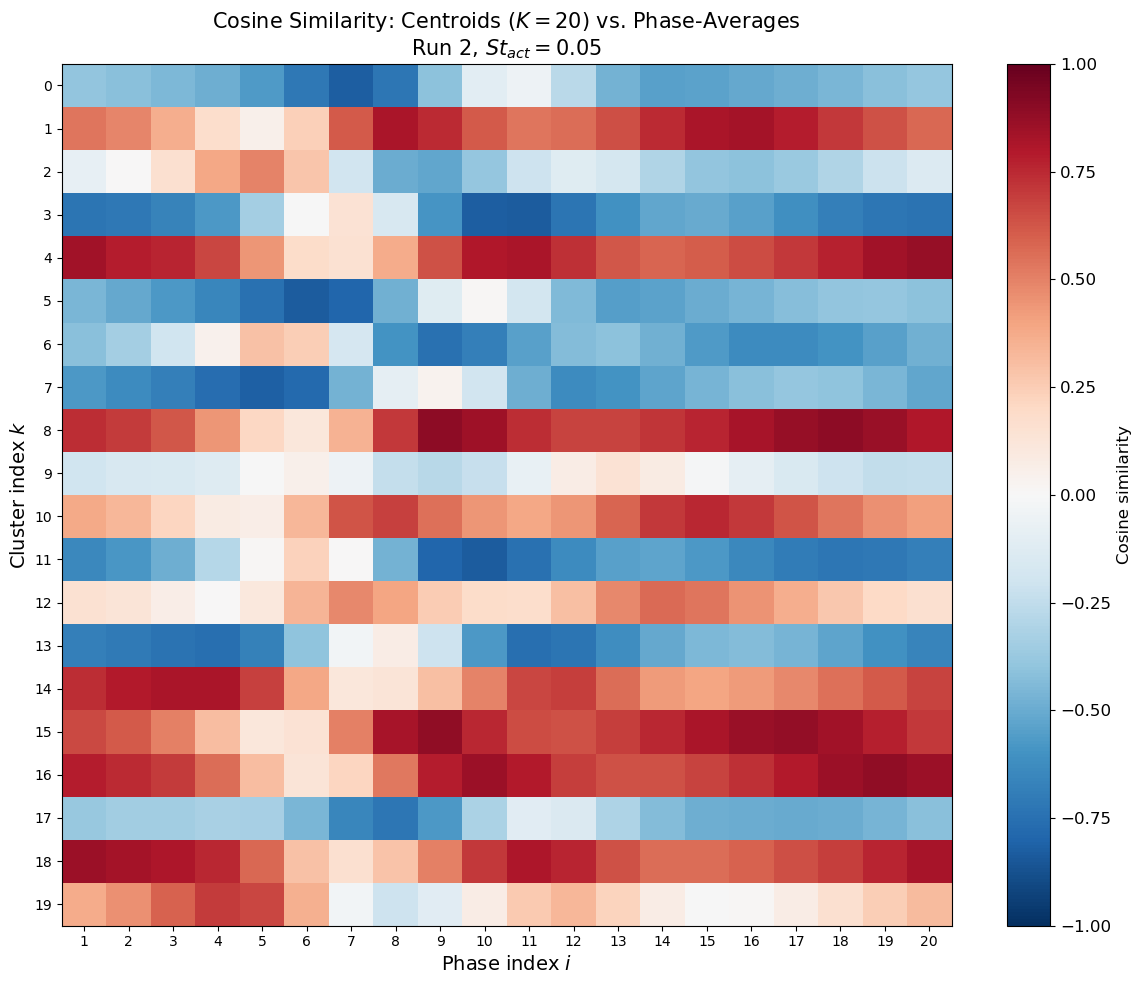

In [8]:
# ============================================================================
# Visualize the similarity matrix as a heatmap
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(S, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1,
               interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, label='Cosine similarity')

ax.set_xlabel('Phase index $i$', fontsize=14)
ax.set_ylabel('Cluster index $k$', fontsize=14)
ax.set_title(f'Cosine Similarity: Centroids ($K={K}$) vs. Phase-Averages\n'
             f'Run {RUN_ID}, $St_{{act}} = {ST_ACT}$', fontsize=15)

ax.set_xticks(range(N_phases))
ax.set_xticklabels([f'{i+1}' for i in range(N_phases)], fontsize=10)
ax.set_yticks(range(K))
ax.set_yticklabels([f'{k}' for k in range(K)], fontsize=10)

plt.tight_layout()
save_path = os.path.join(FIGURE_DIR, f'similarity_matrix_K{K}_RUN{RUN_ID}.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to {save_path}')
plt.show()

In [9]:
# ============================================================================
# Optimal assignment using the Hungarian algorithm
# ============================================================================
# We want to maximize total |similarity|, so we use the negative of |S|
# as the cost matrix (linear_sum_assignment minimizes by default).

cost_matrix = -np.abs(S)  # negate so that minimization = maximization
row_ind, col_ind = linear_sum_assignment(cost_matrix)

print('Optimal centroid → phase assignment (Hungarian algorithm):')
print(f'{"Cluster":>8s} {"Phase":>6s} {"sim":>8s} {"Phase angle":>12s}')
print('-' * 40)
for k, i in zip(row_ind, col_ind):
    phase_deg = 360 * i / N_phases
    print(f'{k:8d} {i+1:6d} {S[k,i]:8.4f} {phase_deg:10.0f}°')

total_sim = np.sum(np.abs(S[row_ind, col_ind]))
mean_sim  = np.mean(np.abs(S[row_ind, col_ind]))
print(f'\nTotal |similarity|: {total_sim:.4f}')
print(f'Mean  |similarity|: {mean_sim:.4f}')

Optimal centroid → phase assignment (Hungarian algorithm):
 Cluster  Phase      sim  Phase angle
----------------------------------------
       0      7  -0.8246        108°
       1     16   0.8324        270°
       2      5   0.4927         72°
       3     11  -0.8337        180°
       4     20   0.8719        342°
       5      6  -0.8335         90°
       6      9  -0.7429        144°
       7      3  -0.6866         36°
       8     18   0.8924        306°
       9     13   0.1408        216°
      10     15   0.7501        252°
      11     10  -0.8324        162°
      12     14   0.5652        234°
      13     12  -0.7337        198°
      14      2   0.7926         18°
      15     17   0.8780        288°
      16     19   0.8842        324°
      17      8  -0.7195        126°
      18      1   0.8592          0°
      19      4   0.6961         54°

Total |similarity|: 14.8626
Mean  |similarity|: 0.7431


---

## Section 5: Diagnostic Visualizations


Figure saved to figures\centroid_vs_phase_rank1_K20_RUN2.png


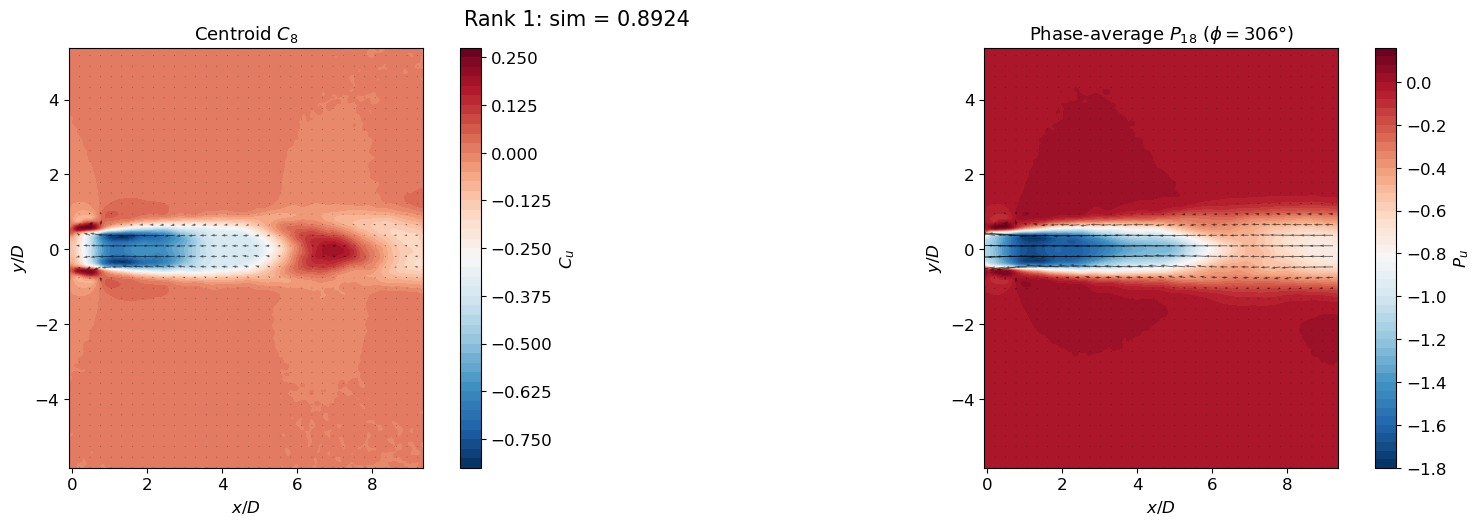

Figure saved to figures\centroid_vs_phase_rank2_K20_RUN2.png


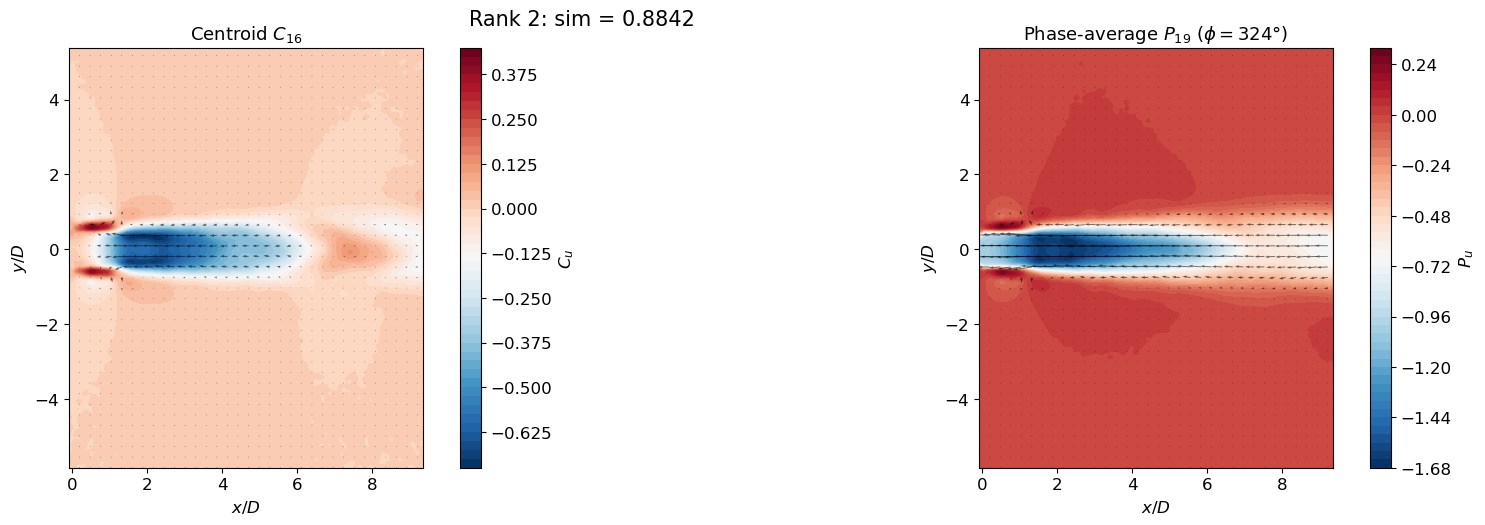

Figure saved to figures\centroid_vs_phase_rank3_K20_RUN2.png


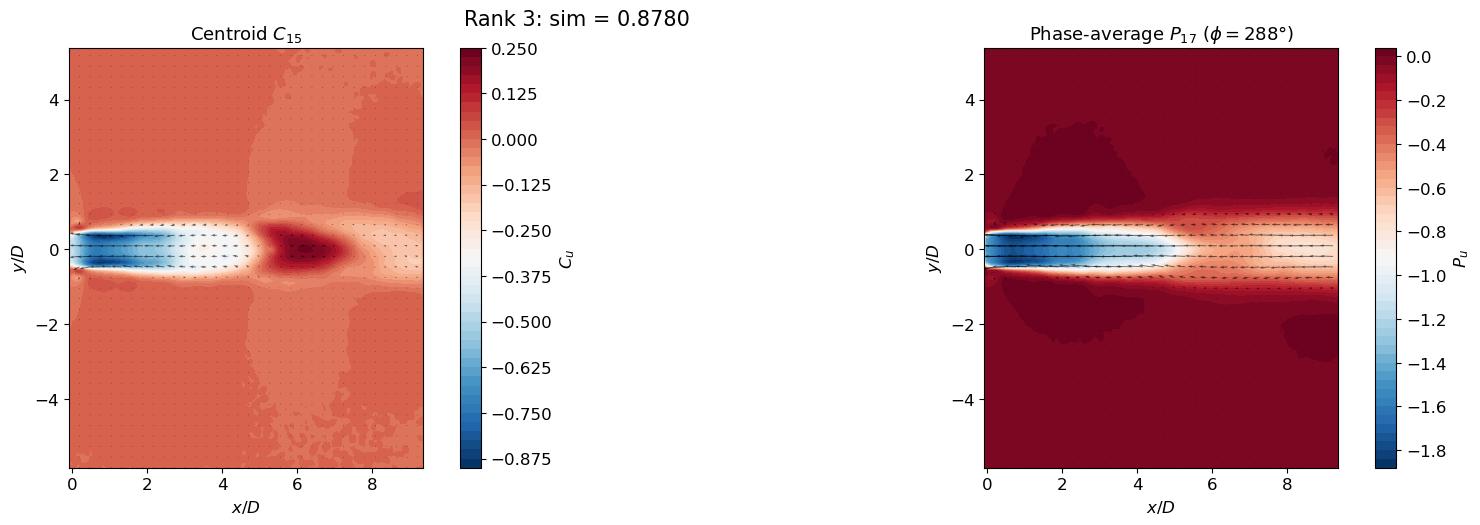

Figure saved to figures\centroid_vs_phase_rank4_K20_RUN2.png


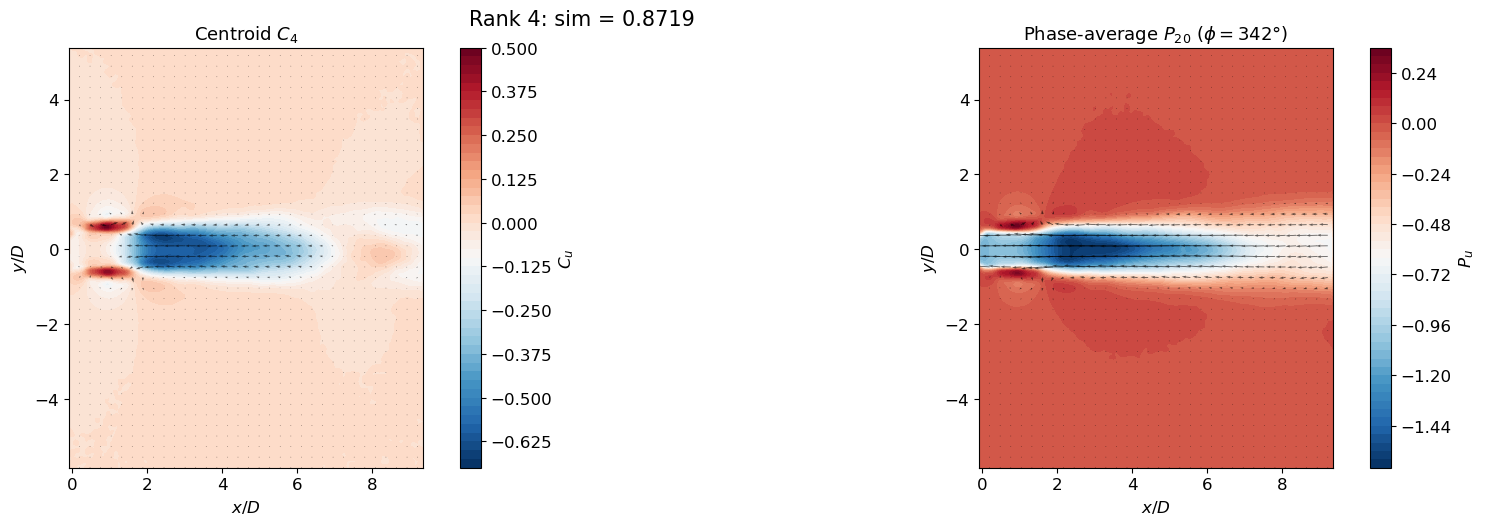

Figure saved to figures\centroid_vs_phase_rank5_K20_RUN2.png


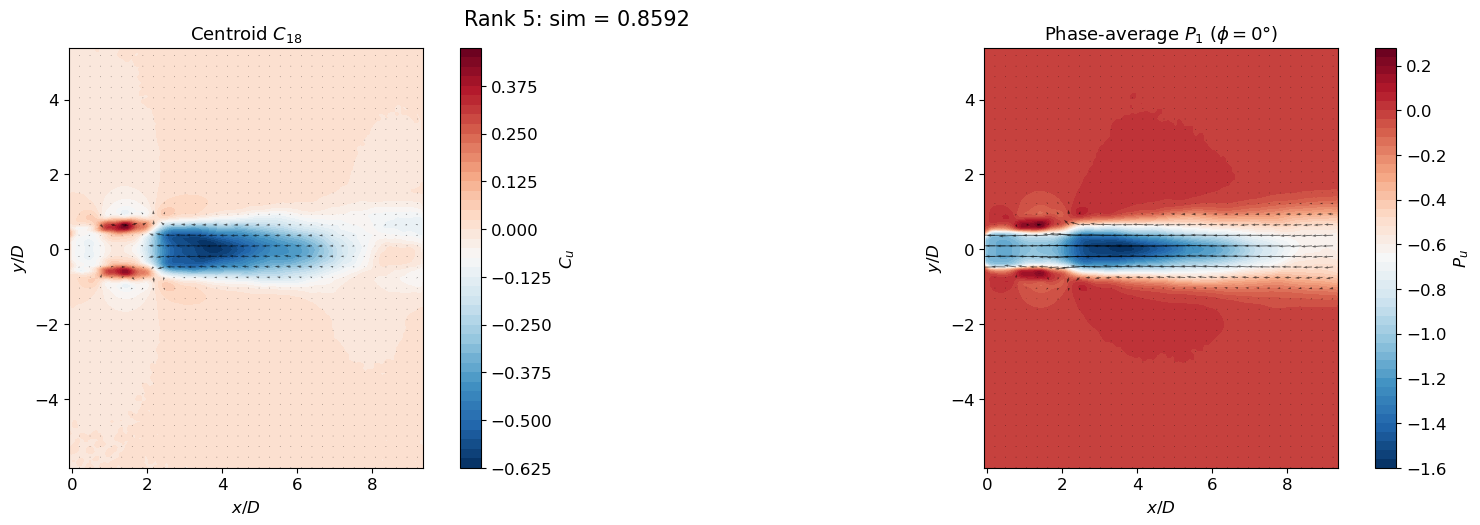

In [10]:
# ============================================================================
# Visualize the top N best-matched centroid–phase pairs
# ============================================================================

N_SHOW = min(5, K)  # number of pairs to visualize

# Sort by |similarity| descending
pair_sims = np.abs(S[row_ind, col_ind])
sorted_idx = np.argsort(-pair_sims)  # descending

for rank in range(N_SHOW):
    idx = sorted_idx[rank]
    k = row_ind[idx]
    i = col_ind[idx]
    sim_val = S[k, i]
    phase_deg = 360 * i / N_phases

    # --- Extract 2D fields ---
    C_u = centroids[k, :half].reshape(NX, NY)
    C_v = centroids[k, half:].reshape(NX, NY)

    P_u = phase_avg_fluct[i, :half].reshape(NX, NY)
    P_v = phase_avg_fluct[i, half:].reshape(NX, NY)

    # --- Plot side by side ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

    # Left: Centroid
    ax = axes[0]
    cont = ax.contourf(X_grid, Y_grid, C_u, levels=50, cmap='RdBu_r')
    plt.colorbar(cont, ax=ax, label=r'$C_u$')
    ax.quiver(X_grid[::8, ::8], Y_grid[::8, ::8],
              C_u[::8, ::8], C_v[::8, ::8],
              scale=20, color='k', alpha=0.6)
    ax.set_title(f'Centroid $C_{{{k}}}$', fontsize=13)
    ax.set_xlabel(r'$x/D$')
    ax.set_ylabel(r'$y/D$')
    ax.set_aspect('equal')

    # Right: Phase-average
    ax = axes[1]
    cont = ax.contourf(X_grid, Y_grid, P_u, levels=50, cmap='RdBu_r')
    plt.colorbar(cont, ax=ax, label=r'$P_u$')
    ax.quiver(X_grid[::8, ::8], Y_grid[::8, ::8],
              P_u[::8, ::8], P_v[::8, ::8],
              scale=20, color='k', alpha=0.6)
    ax.set_title(f'Phase-average $P_{{{i+1}}}$ '
                 rf'($\phi = {phase_deg:.0f}°$)', fontsize=13)
    ax.set_xlabel(r'$x/D$')
    ax.set_ylabel(r'$y/D$')
    ax.set_aspect('equal')

    fig.suptitle(f'Rank {rank+1}: sim = {sim_val:.4f}', fontsize=15, y=1.02)

    save_path = os.path.join(FIGURE_DIR, f'centroid_vs_phase_rank{rank+1}_K{K}_RUN{RUN_ID}.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f'Figure saved to {save_path}')
    plt.show()

Figure saved to figures\similarity_profiles_K20_RUN2.png


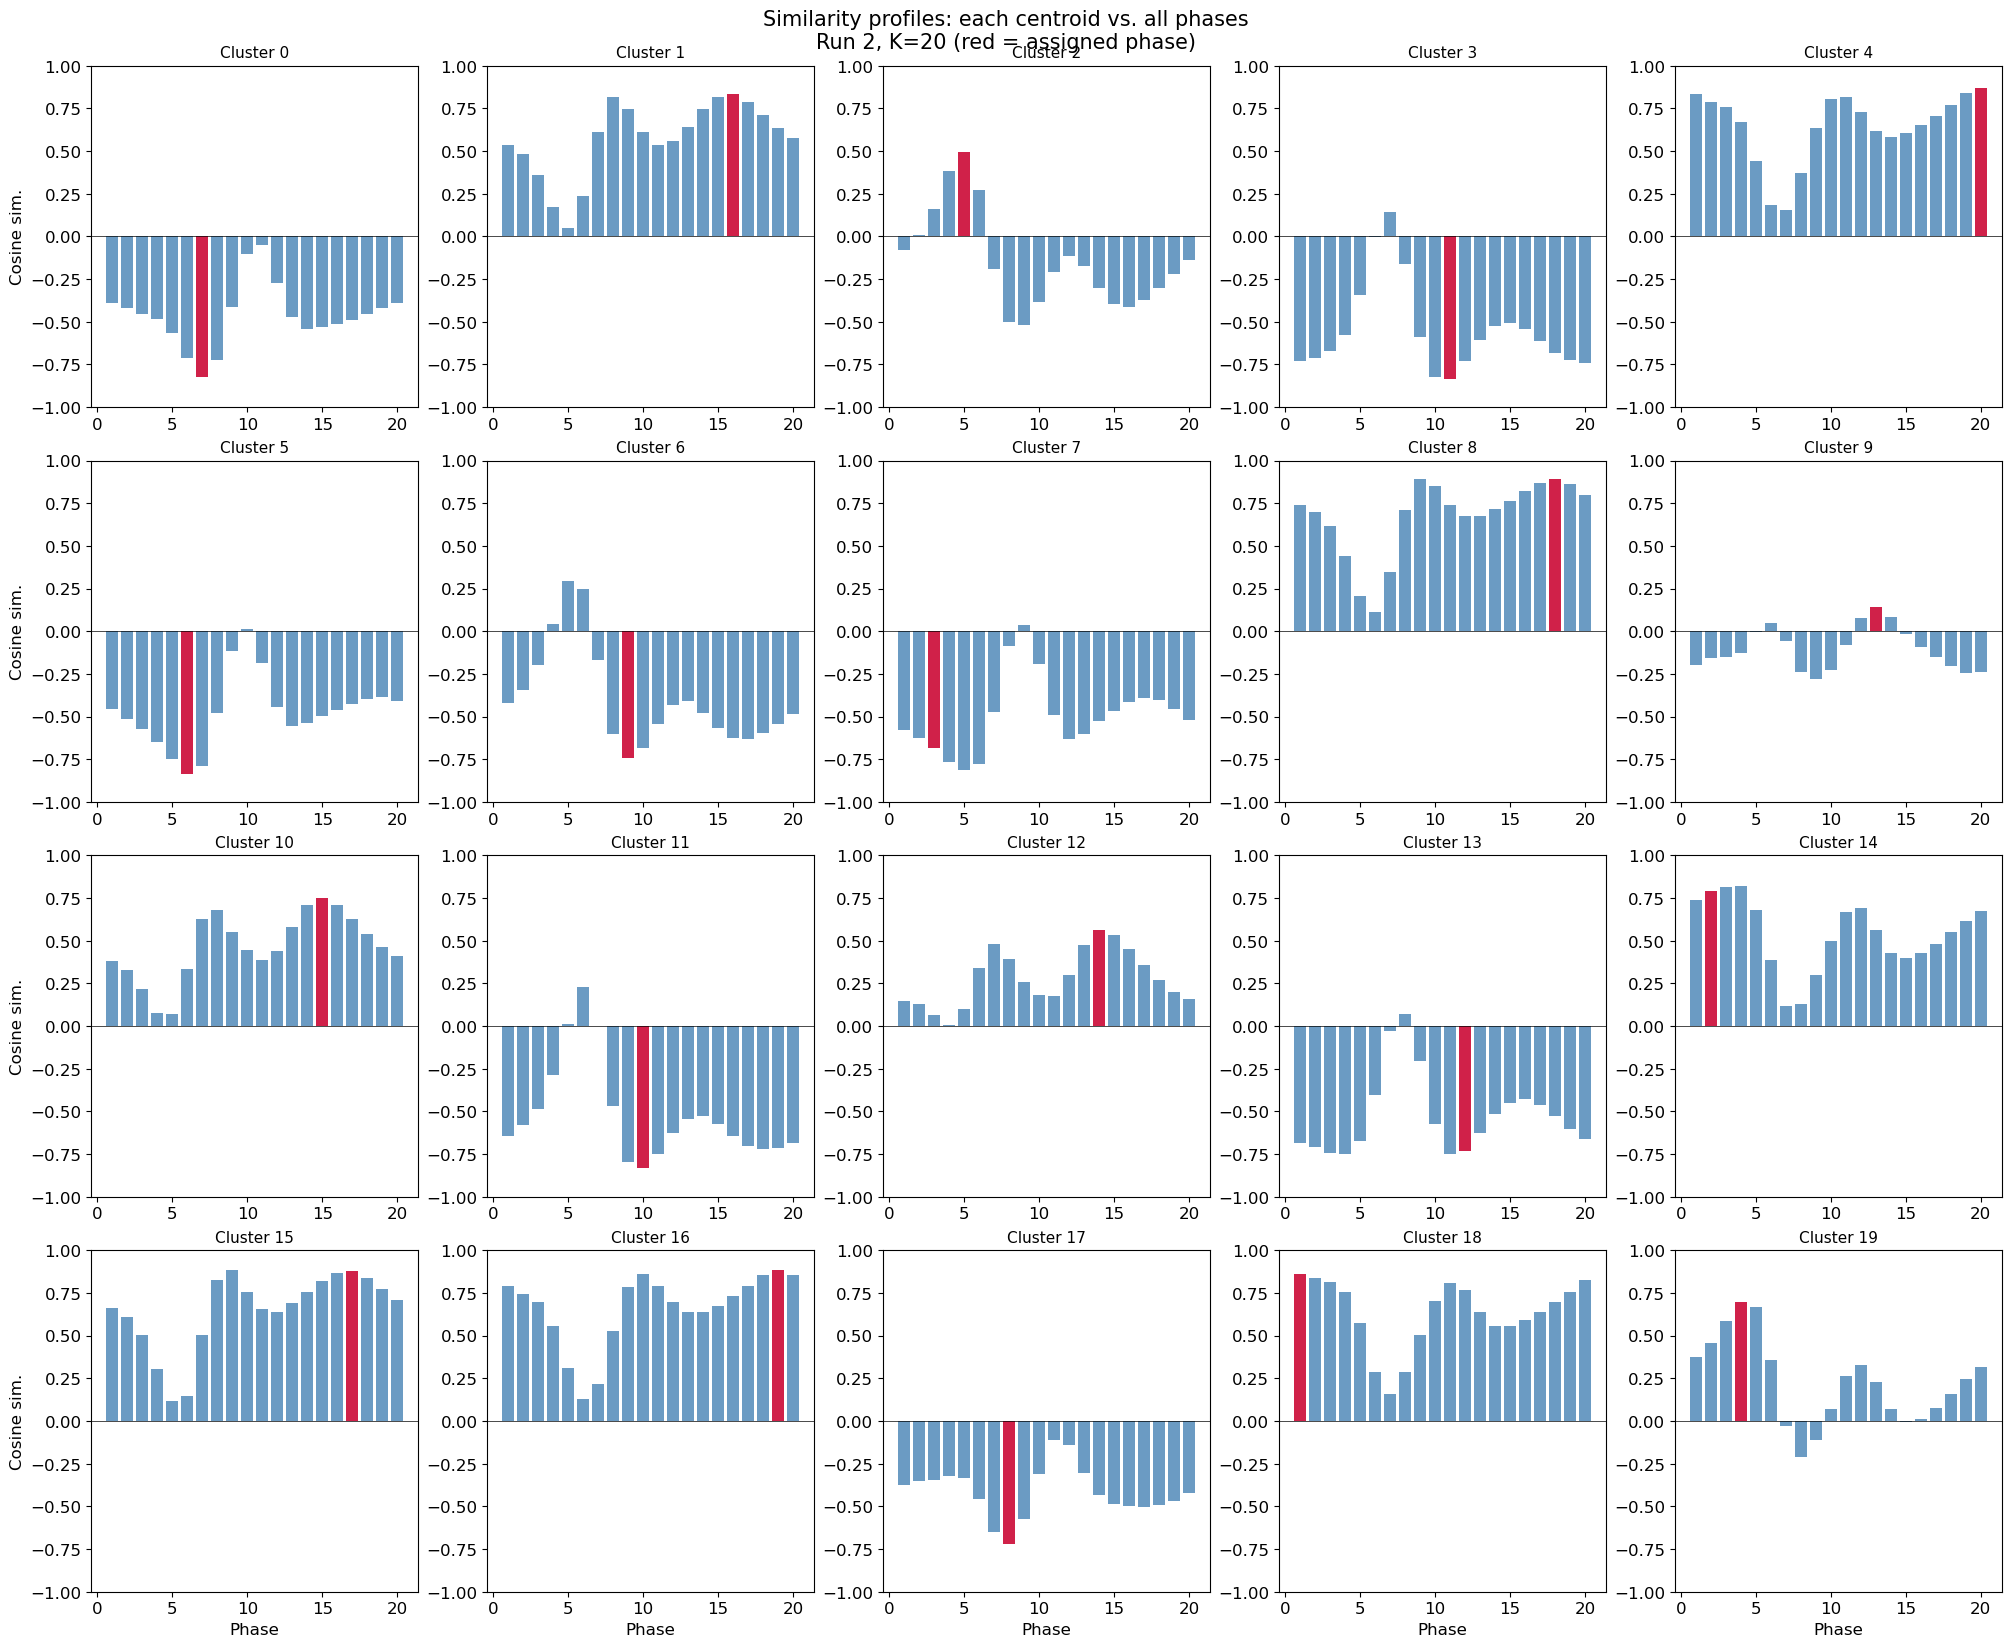

In [11]:
# ============================================================================
# Similarity profile: each centroid vs. all 20 phases
# ============================================================================

fig, axes = plt.subplots(4, 5, figsize=(20, 16), constrained_layout=True)
axes = axes.flatten()

for k in range(K):
    ax = axes[k]
    ax.bar(range(1, N_phases + 1), S[k, :], color='steelblue', alpha=0.8)
    ax.set_title(f'Cluster {k}', fontsize=11)
    ax.set_ylim(-1, 1)
    ax.axhline(0, color='k', lw=0.5)

    # Highlight the assigned phase
    assigned_phase = col_ind[np.where(row_ind == k)[0][0]]
    ax.bar(assigned_phase + 1, S[k, assigned_phase], color='crimson', alpha=0.9)

    if k >= 15:
        ax.set_xlabel('Phase')
    if k % 5 == 0:
        ax.set_ylabel('Cosine sim.')

fig.suptitle(f'Similarity profiles: each centroid vs. all phases\n'
             f'Run {RUN_ID}, K={K} (red = assigned phase)',
             fontsize=15, y=1.02)

save_path = os.path.join(FIGURE_DIR, f'similarity_profiles_K{K}_RUN{RUN_ID}.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to {save_path}')
plt.show()

---

## Section 6: Interpretation

The analysis of the executed clustering and similarity metrics yields several key physical and statistical insights:

1. **Uniformity of Cluster Sizes:** The unsupervised KMeans algorithm (with K=20) on the SPCA scores successfully partitioned the 2030 snapshots into 20 clusters of remarkably uniform size (between 101 and 102 snapshots each). Since the actuation is periodic and deterministic, the experimental dataset contains exactly 101.5 snapshots per phase on average ( / 20 = 101.5$). The fact that the blind clustering recovered this exact uniform distribution is the first strong indicator that the clusters are naturally dividing the data according to the underlying actuation cycle.

2. **High Structural Correlation:** The cosine similarity matrix produced a mean absolute similarity of 0.743 across the optimal assignments, with the exact best-matched pairs showing similarity values approaching .90$ (e.g., .892, 0.884, 0.878$). A cosine similarity near $ (or $-1$) suggests that the velocity field represented by the cluster centroid ($\mathbf{C}_k$) is geometrically almost identical to the physically measured, hardware-triggered phase-average ($\mathbf{P}'_i$). Negative values (e.g., $-0.833$) reflect the same coherent flow structures but with opposing signs, standard for oscillatory phenomena.

3. **Validation of the Manifold Hypothesis:** The fundamental premise of the Manifold Hypothesis in this context implies that the dynamics of the flow are largely confined to a low-dimensional space described by a few latent variables—most notably, the phase of the synthetic jet actuation. The optimal one-to-one pairing of K=20 blind cluster centroids to the 20 physical actuation phases, supplemented by the high spatial correlation observed in the resultant velocity vector fields, unambiguously confirms this hypothesis. The dimensionality reduction (SPCA) successfully extracted the governing deterministic dynamics, such that clustering the low-dimensional scores blindly uncovers the exact coherent structures typically only visible via external phase-locked triggers.